In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import OrthogonalMatchingPursuit
import copy
from collections import Counter
import json

import warnings

# Filtrer les avertissements spécifiques
warnings.filterwarnings("ignore", message="Orthogonal matching pursuit ended prematurely due to linear dependence in the dictionary")

In [2]:
def bin_to_pattern(x):
    return [ [1-int(i), int(i)] for i in x ]
def create_specific_patterns(mode1,mode2,size):
    pats =[]
    for i in range(2):
        for j in range(2):
            pats.append( [[1,1]]*mode1 + bin_to_pattern(str(i)) + [[1,1]]*(mode2-mode1-1) + bin_to_pattern(str(j)) + [[1,1]]*(size-mode1-(mode2-mode1-1)-2) )
    return pats
def create_specific_patterns3(mode1,mode2,mode3,size):
    pats =[]
    for i in range(2):
        for j in range(2):
            for k in range(2):
                pats.append( [[1,1]]*mode1 + bin_to_pattern(str(i)) + [[1,1]]*(mode2-mode1-1) + bin_to_pattern(str(j)) + [[1,1]]*(mode3-(mode2-mode1-1)-mode1-2) + bin_to_pattern(str(k)) + [[1,1]]*(size -mode1-(mode2-mode1-1)-(mode3-(mode2-mode1-1)-mode1-2)-3) )
    return pats
def create_specific_patterns4(mode1,mode2,mode3,mode4,size):
    pats = []
    temp_pats = create_specific_patterns3(mode1,mode2,mode3,size)
    for p in temp_pats:
        for k in range(2):
            p_prime = copy.deepcopy(p)
            p_prime[mode4] = bin_to_pattern(str(k))[0]
            pats.append(p_prime)
    return pats
def create_specific_patterns5(mode1, mode2, mode3, mode4, mode5, size):
    """
    Generate specific patterns for 5 modes.
    """
    pats = []
    temp_pats = create_specific_patterns4(mode1, mode2, mode3, mode4, size)
    for p in temp_pats:
        for k in range(2):
            p_prime = copy.deepcopy(p)
            p_prime[mode5] = bin_to_pattern(str(k))[0]
            pats.append(p_prime)
    return pats
def create_specific_patterns8(mode1, mode2, mode3, mode4, mode5, mode6, mode7, mode8, size):
    """
    Generate specific patterns for 8 modes.
    """
    pats = []
    temp_pats = create_specific_patterns5(mode1, mode2, mode3, mode4, mode5, size)
    for p in temp_pats:
        for k in range(2):
            p_prime = copy.deepcopy(p)
            p_prime[mode6] = bin_to_pattern(str(k))[0]
            for l in range(2):
                p_prime2 = copy.deepcopy(p_prime)
                p_prime2[mode7] = bin_to_pattern(str(l))[0]
                for m in range(2):
                    p_prime3 = copy.deepcopy(p_prime2)
                    p_prime3[mode8] = bin_to_pattern(str(m))[0]
                    pats.append(p_prime3)
    return pats
def dev_pattern(pat):
    f = np.array([1])
    for i in pat:
        f = np.kron(f,i)
    return f

<h2>Game modeling</h2>

In [3]:
def stringify(seq):
    string = ''
    for n in seq:
        string+=str(n)
    return string

In [4]:
n = 12
sequence_list = np.array([np.array(list(bin(i)[3:]),dtype=np.int32) for i in range(2**n, 2**(n+1))])
len(sequence_list)

4096

In [5]:
def generate_rules_and_rewards(num_rules=5, rule_length=4, reward_range=(1, 20), sequence_length=12):
    """
    Generate rules, rewards, and starting positions for the rules.
    """
    rules = set()
    rewards = []
    starting_positions = []

    while len(rules) < num_rules:
        rule = tuple(np.random.randint(0, 2, size=rule_length))  # Generate a random rule
        if rule not in rules:
            rules.add(rule)
            reward = np.random.randint(reward_range[0], reward_range[1])  # Generate a random reward
            rewards.append(reward)
            # Generate one or more starting positions for the rule
            positions = np.random.choice(range(sequence_length - rule_length + 1), size=np.random.randint(1, 12-rule_length), replace=False)
            starting_positions.append(list(positions))

    return list(rules), rewards, starting_positions


def estimate_cost(sequence, rules, rewards, starting_positions=None):
    """
    Estimate the cost of a sequence based on the rules, rewards, and starting positions.
    """
    if rules== [] or rewards == []:
        return 0

    if starting_positions is None:
        starting_positions = [list(range(len(sequence) - len(rules[0]) + 1))] * len(rules)

    reward = 0
    rule_length = len(rules[0])

    for rule, rule_reward, positions in zip(rules, rewards, starting_positions):
        for k in positions:  # Only check the specified starting positions
            if k + rule_length <= len(sequence) and np.all(sequence[k:k + rule_length] == rule):
                reward += rule_reward
                
    return np.abs(reward)

In [6]:
def monte_carlo_compressive_learning(Phi,sequence_cost,sample_size=200,threshold=20):

    #Sample
    sample_index = np.random.randint(0,len(sequence_list),sample_size)
    sequence_cost_spectrum = np.zeros_like(sequence_cost)
    sequence_cost_spectrum[sample_index] = sequence_cost[sample_index]

    #Threshold
    sequence_cost_spectrum[sequence_cost_spectrum<threshold]=0

    #Measurements
    y = []
    y = np.array(Phi * np.matrix(sequence_cost_spectrum).T).T[0]
    y = np.array(y)

    #Matching pursuit
    omp = OrthogonalMatchingPursuit(n_nonzero_coefs=10)
    omp.fit(Phi, y)
    coefficients = np.array([ i if i>0 else 0 for i in omp.coef_])

    support = np.where(coefficients>0)[0]
    if len(support) != 0:
        maximum = np.max(sequence_cost[support])
        argmax = support[np.argmax(sequence_cost[support])]

        return (argmax,maximum)
    else:
        return (None,0)

In [7]:
from scipy.optimize import dual_annealing

# Define the objective function
def my_f(x):
    """
    Objective function to minimize.
    Converts x to an integer index and returns the negative sequence cost.
    """
    x = int(round(x[0]))  # Ensure x is a single integer index
    if 0 <= x < len(sequence_cost):  # Check bounds
        return -sequence_cost[x]
    else:
        return float('inf')  # Return a large value if out of bounds

# Define bounds for the single-dimensional problem
# bounds = [(0, len(sequence_cost) - 1)]  # Single-dimensional bounds

In [8]:
import numpy as np

def random_repartition(nb_rules,into=5):
    """
    Generate a random repartition of 5 values whose sum equals nb_rules.
    """
    values = np.random.multinomial(nb_rules, [1/into]*into)
    return values


<h2>Step 1</h2>

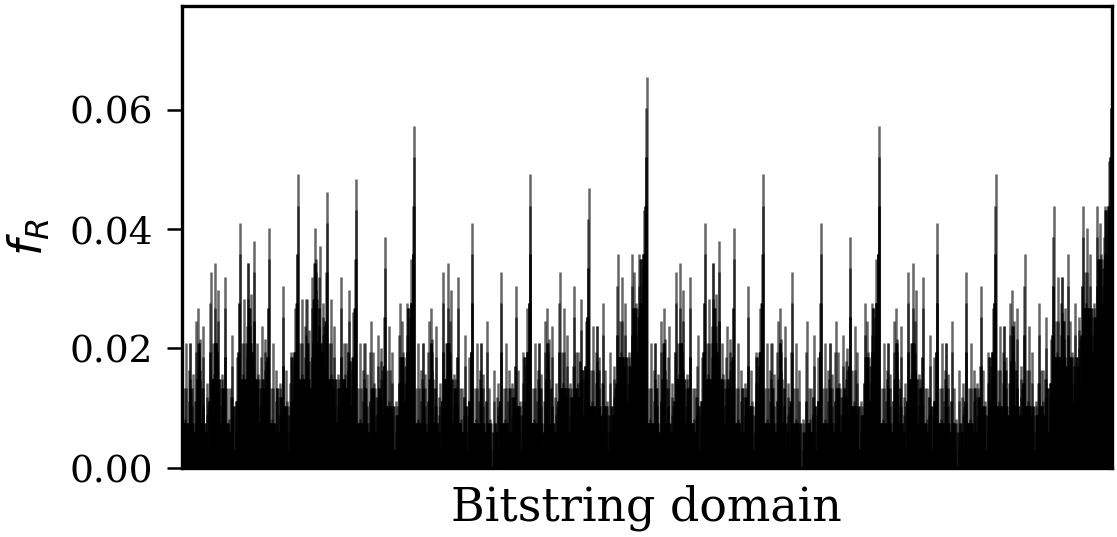

In [109]:
import matplotlib as mpl

import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
from pathlib import Path

font_path = Path(r"C:\Windows\Fonts\lmroman10-regular.otf")
fm.fontManager.addfont(str(font_path))

mpl.rcParams.update({
    # Font
    "font.family": "serif",
    "font.serif": ["DejaVu Serif"],  # guaranteed to exist
    "text.usetex": False,

    # Font sizes (tweak once, reuse everywhere)
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,

    # Axes appearance
    "axes.linewidth": 0.8,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
    "xtick.minor.width": 0.4,
    "ytick.minor.width": 0.4,

    # No grids by default
    "axes.grid": False,

    # Figure
    "figure.dpi": 300,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.02,
})

x2,y = [i for i in np.arange(len(sequence_list))],sequence_cost

fig, ax = plt.subplots(figsize=(4, 2))

markerline, stemlines, baseline = ax.stem(
    x2, y,
    linefmt="k-",
    markerfmt=" ",
    basefmt=" "
)

# Make spikes light and thin
plt.setp(stemlines, linewidth=0.6, alpha=0.6)

# Axes labels
ax.set_xlabel("Bitstring domain")
ax.set_ylabel(r"$f_R$")

# Reduce x-axis clutter
ax.set_xticks([])
ax.margins(x=0)

# Optional: tighten y-axis
ax.set_ylim(bottom=0)

plt.show()

fig.savefig("figure.pdf")
plt.close()

In [ ]:
#Random
Phi_random = np.random.rand(250,2**n)

#Quadruplets
all_pat = []
for i in range(n-3):
    all_pat += create_specific_patterns4(i,i+1,i+2,i+3,n)
Phi_quad = np.array([dev_pattern(p) for p in all_pat])

#Quintuplets
all_pat = []
for i in range(n-4):
    all_pat += create_specific_patterns5(i,i+1,i+2,i+3,i+4,n)
Phi_quint = np.array([dev_pattern(p) for p in all_pat])

#Parameters
thresh = np.percentile(sequence_cost,90)

plot_res = {}
plot_res["annealing"] = []
plot_res["random"] = []
plot_res["quadruplets"] = []
plot_res["quintuplets"] = []

rg = np.concatenate((np.arange(50,140,10),np.arange(150,400,25)))

for sample_size in rg:
    print(sample_size)

    average_distance = {}
    average_distance["annealing"] = []
    average_distance["random"] = []
    average_distance["quadruplets"] = []
    average_distance["quintuplets"] = []

    for _ in range(1000):
        
        # Annealing
        bounds = [(0, len(sequence_cost) - 1)]
        res = dual_annealing(my_f, bounds=bounds, maxiter=sample_size,no_local_search=True)
        argmax = round(res.x[0])
        maximum = -res.fun
        average_distance["annealing"].append(np.max(sequence_cost) - maximum)

        #Random
        argmax,maximum = monte_carlo_compressive_learning(Phi_random,sequence_cost,sample_size=sample_size,threshold=thresh)
        average_distance["random"].append(np.max(sequence_cost) - maximum)

        #Quadruplets
        argmax,maximum = monte_carlo_compressive_learning(Phi_quad,sequence_cost,sample_size=sample_size,threshold=thresh)
        average_distance["quadruplets"].append(np.max(sequence_cost) - maximum)

        #Quintuplets
        argmax,maximum = monte_carlo_compressive_learning(Phi_quint,sequence_cost,sample_size=sample_size,threshold=thresh)
        average_distance["quintuplets"].append(np.max(sequence_cost) - maximum)

    plot_res["annealing"].append(round(np.average(average_distance["annealing"]),ndigits=5))
    plot_res["random"].append(round(np.average(average_distance["random"]),ndigits=5))
    plot_res["quadruplets"].append(round(np.average(average_distance["quadruplets"]),ndigits=5))
    plot_res["quintuplets"].append(round(np.average(average_distance["quintuplets"]),ndigits=5))

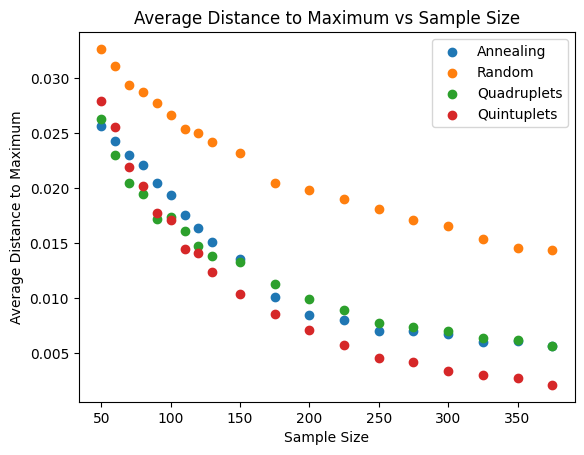

In [28]:
rg = np.concatenate((np.arange(50,140,10),np.arange(150,400,25)))
plt.scatter(rg,plot_res["annealing"],label="Annealing")
plt.scatter(rg,plot_res["random"],label="Random")
plt.scatter(rg,plot_res["quadruplets"],label="Quadruplets")
plt.scatter(rg,plot_res["quintuplets"],label="Quintuplets")
plt.xlabel("Sample Size")
plt.ylabel("Average Distance to Maximum")
plt.title("Average Distance to Maximum vs Sample Size")
plt.legend()
plt.show()

<h2>Other tests</h2>

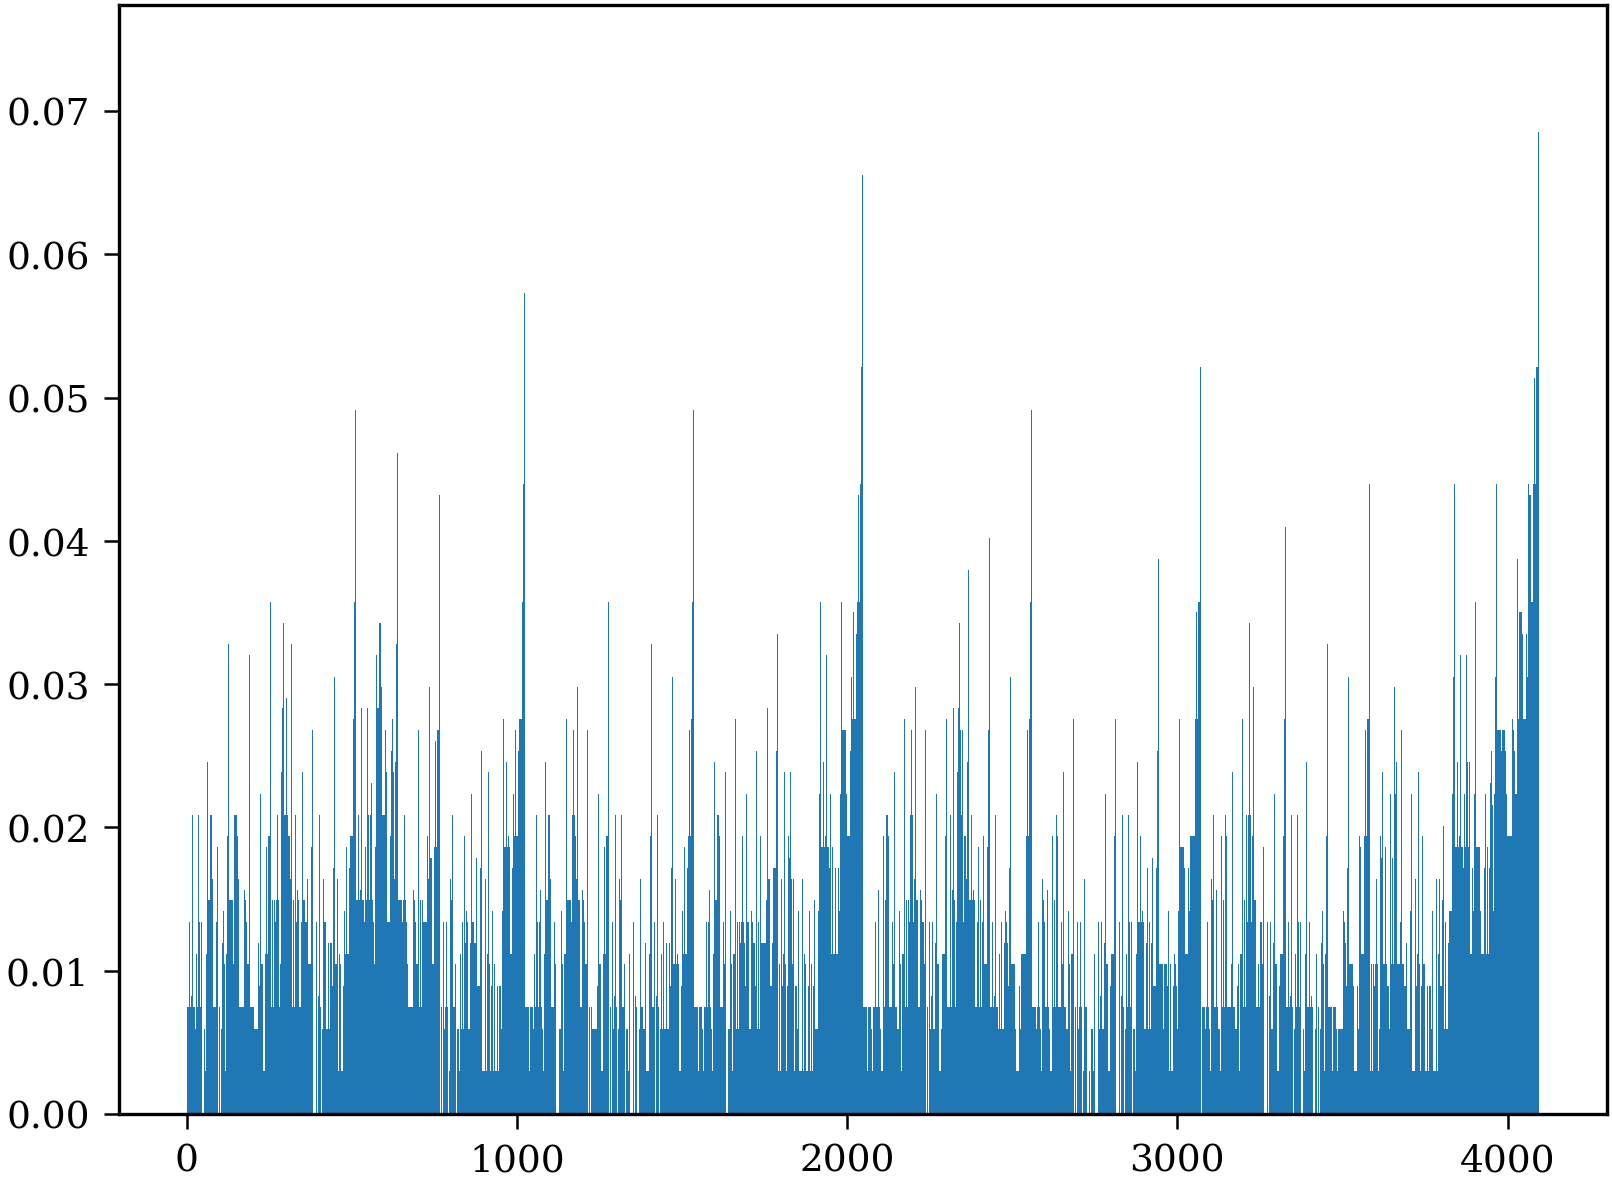

np.float64(0.07371100556533038)

In [96]:
def generate_problem(total_nb_rules=5):
    # nb_rules = random_repartition(total_nb_rules,into=3)
    nb_rules = np.array([3, 1, 1])

    rules1, rewards1,pos1 = generate_rules_and_rewards(num_rules=nb_rules[0],rule_length=4)
    rules2, rewards2,pos2 = generate_rules_and_rewards(num_rules=nb_rules[1],rule_length=5)
    rules3, rewards3,pos3 = generate_rules_and_rewards(num_rules=nb_rules[2],rule_length=6)
    # pos1 = [[0,2,4,6,8]]*nb_rules
    # pos1 = [np.arange(0,4)]*nb_rules
    # pos1 = [ [i] for i in np.random.randint(0,8,nb_rules)]

    sequence_cost = []
    for sequence in sequence_list:
        rew = 0
        rew += estimate_cost(sequence,rules1, rewards1)
        rew += estimate_cost(sequence,rules2, rewards2)
        rew += estimate_cost(sequence,rules3, rewards3)
        sequence_cost.append(rew)
    sequence_cost = np.array(sequence_cost)
    sequence_cost = sequence_cost /np.linalg.norm(sequence_cost)

    return sequence_cost

sequence_cost = generate_problem(5)
real_argmax = np.argmax(sequence_cost)
real_maximum = sequence_cost[real_argmax]
plt.bar([i for i in np.arange(len(sequence_list))],sequence_cost,width=1.5)
plt.show()
real_maximum

In [102]:
def hamming_distance(a, b):
    x = np.array(list(a),dtype=np.int32)
    y = np.array(list(b),dtype=np.int32)
    return np.sum(x != y)

max_value = np.max(sequence_cost)
max_indices = np.where(sequence_cost == max_value)[0]
max_sequence = [ stringify(sequence_list[i]) for i in max_indices]

In [104]:
#Random
Phi_random = np.random.rand(250,2**n)

#Quadruplets
all_pat = []
for i in range(n-3):
    all_pat += create_specific_patterns4(i,i+1,i+2,i+3,n)
Phi_quad = np.array([dev_pattern(p) for p in all_pat])

#Quintuplets
all_pat = []
for i in range(n-4):
    all_pat += create_specific_patterns5(i,i+1,i+2,i+3,i+4,n)
Phi_quint = np.array([dev_pattern(p) for p in all_pat])

#Parameters
thresh = np.percentile(sequence_cost,90)
sample_size = 250

distance = {}
distance["annealing"] = []
distance["random"] = []
distance["quadruplets"] = []
distance["quintuplets"] = []

ham_dista = {}
ham_dista["annealing"] = []
ham_dista["random"] = []
ham_dista["quadruplets"] = []
ham_dista["quintuplets"] = []

for ct in range(5000):
    
    if ct%100==0:
        print(ct)

    # Annealing
    bounds = [(0, len(sequence_cost) - 1)]
    res = dual_annealing(my_f, bounds=bounds, maxiter=sample_size,no_local_search=True)
    argmax = round(res.x[0])
    maximum = -res.fun
    distance["annealing"].append(np.max(sequence_cost) - maximum)

    bin_argmax = format(argmax, '012b')
    ham_dist = [hamming_distance(bin_argmax, b) for b in max_sequence]
    ham_dista["annealing"].append(min(ham_dist))

    #Random
    argmax,maximum = monte_carlo_compressive_learning(Phi_random,sequence_cost,sample_size=sample_size,threshold=thresh)
    distance["random"].append(np.max(sequence_cost) - maximum)

    bin_argmax = format(argmax, '012b')
    ham_dist = [hamming_distance(bin_argmax, b) for b in max_sequence]
    ham_dista["random"].append(min(ham_dist))

    #Quadruplets
    argmax,maximum = monte_carlo_compressive_learning(Phi_quad,sequence_cost,sample_size=sample_size,threshold=thresh)
    distance["quadruplets"].append(np.max(sequence_cost) - maximum)

    bin_argmax = format(argmax, '012b')
    ham_dist = [hamming_distance(bin_argmax, b) for b in max_sequence]
    ham_dista["quadruplets"].append(min(ham_dist))

    #Quintuplets
    argmax,maximum = monte_carlo_compressive_learning(Phi_quint,sequence_cost,sample_size=sample_size,threshold=thresh)
    distance["quintuplets"].append(np.max(sequence_cost) - maximum)

    bin_argmax = format(argmax, '012b')
    ham_dist = [hamming_distance(bin_argmax, b) for b in max_sequence]
    ham_dista["quintuplets"].append(min(ham_dist))

0
100
200
300
400
500
600
700
800
900
1000
1100
1200
1300
1400
1500
1600
1700
1800
1900
2000
2100
2200
2300
2400
2500
2600
2700
2800
2900
3000
3100
3200
3300
3400
3500
3600
3700
3800
3900
4000
4100
4200
4300
4400
4500
4600
4700
4800
4900


In [105]:
def count_intervals(data, epsilon=0.015):

    values = np.array(data)

    # Count values equal to 0
    count_zero = np.sum(values == 0)

    # Count values in intervals: (0, epsilon], (epsilon, 2*epsilon], ...
    max_value = np.max(values)
    num_intervals = int(np.ceil(max_value / epsilon))
    interval_counts = [count_zero]

    for i in range(num_intervals):
        lower = i * epsilon
        upper = (i + 1) * epsilon
        count = np.sum((values > lower) & (values <= upper))
        interval_counts.append(count)

    return interval_counts

sigma = np.std(sequence_cost)

print("nb_intervals:", int(np.ceil(np.max(sequence_cost) / sigma)))

interval_counts = {}
interval_counts["annealing"] = count_intervals(distance["annealing"],sigma)
interval_counts["random"] = count_intervals(distance["random"],sigma)
interval_counts["quadruplets"] = count_intervals(distance["quadruplets"],sigma)
interval_counts["quintuplets"] = count_intervals(distance["quintuplets"],sigma)

print("annealing")
for val in interval_counts["annealing"]:
    print(val)
print("random")
for val in interval_counts["random"]:
    print(val)
print("quadruplets")
for val in interval_counts["quadruplets"]:
    print(val)
print("quintuplets")
for val in interval_counts["quintuplets"]:
    print(val)


nb_intervals: 8
annealing
2289
1256
894
517
44
random
304
571
1093
1858
1102
72
quadruplets
2878
1460
518
121
23
quintuplets
2446
1518
684
290
61
1


In [106]:
from collections import Counter

ham_count = {}
ham_count["annealing"] = []
ham_count["random"] = []
ham_count["quadruplets"] = []
ham_count["quintuplets"] = []

# Partition and count each value in ham_dista["annealing"]
counts = Counter(ham_dista["annealing"])
for value, count in sorted(counts.items()):
    ham_count["annealing"].append(count)

counts = Counter(ham_dista["random"])
for value, count in sorted(counts.items()):
    ham_count["random"].append(count)

counts = Counter(ham_dista["quadruplets"])
for value, count in sorted(counts.items()):
    ham_count["quadruplets"].append(count)

counts = Counter(ham_dista["quintuplets"])
for value, count in sorted(counts.items()):
    ham_count["quintuplets"].append(count)

print(ham_count["annealing"])
print(ham_count["random"])
print(ham_count["quadruplets"])
print(ham_count["quintuplets"])

[2289, 1778, 699, 199, 35]
[304, 1356, 1719, 1138, 439, 37, 7]
[2878, 1689, 375, 47, 9, 2]
[2446, 1819, 564, 153, 18]


In [107]:
# Save interval_counts to a CSV file
import csv
csv_file_intervals = "interval_counts.csv"

# Prepare header and rows
methods = list(interval_counts.keys())
num_intervals = max(len(interval_counts[m]) for m in methods)
header = ["Interval"] + methods

rows = []
for i in range(num_intervals):
    row = [f"Interval {i}"]
    for m in methods:
        if i < len(interval_counts[m]):
            row.append(interval_counts[m][i])
        else:
            row.append("")
    rows.append(row)

with open(csv_file_intervals, mode="w", newline="") as file:
    writer = csv.writer(file)
    writer.writerow(header)
    writer.writerows(rows)
print(f"Interval counts exported to {csv_file_intervals}")

Interval counts exported to interval_counts.csv


In [108]:
import csv

# Export ham_count to CSV: columns are method, hamming distance, count
with open('ham_count2.csv', 'w', newline='') as csvfile:
    writer = csv.writer(csvfile)
    writer.writerow(['Method', 'Hamming Distance', 'Count'])
    for method, counts in ham_count.items():
        for hamming_distance, count in enumerate(counts):
            writer.writerow([method, hamming_distance, count])
print('ham_count exported to ham_count.csv')

ham_count exported to ham_count.csv


Save stuffs

In [30]:
# Save sequence_cost to a file
np.save("sequence_cost.npy", sequence_cost)

# Function to reload sequence_cost
def load_sequence_cost(filename="sequence_cost.npy"):
    return np.load(filename)

In [25]:
# Save plot_res to a file
with open("corrected_curve.json", "w") as file:
    json.dump(plot_res, file)

In [27]:
# Load plot_res from the file
with open("corrected_curve.json", "r") as file:
    plot_res = json.load(file)

In [26]:
import csv

# Define the CSV file name
csv_file = "plot_res.csv"

# Get the keys (methods) and values (results) from plot_res
methods = list(plot_res.keys())
data = list(zip(*[plot_res[method] for method in methods]))

# Write the data to a CSV file
with open(csv_file, mode="w", newline="") as file:
    writer = csv.writer(file)
    
    # Write the header
    writer.writerow(["Sample Size"] + methods)
    
    # Write the rows
    for i, row in enumerate(data):
        writer.writerow([rg[i]] + list(row))

print(f"Data exported to {csv_file}")

Data exported to plot_res.csv
